In [1]:
# Ensure you have at least 2GB free space in Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Project setup
import os
PROJECT_DIR = "/content/drive/MyDrive/DL_Group_MGI1"
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print("Working in:", os.getcwd())

# Install dependencies
!pip install -q torch torchvision lightning matplotlib seaborn pathlib scikit-learn scikit-image wandb iterative-stratification torchmetrics

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [33]:
# Run this everytime you update something in the repo!
REPO = "https://github.com/gabrielcastrob/Deep_learning_WUR"

# if project directory is empty clone the repo, otherwise pull the latest changes
if not os.listdir(PROJECT_DIR):
    !git clone {REPO} {PROJECT_DIR}
else:
    !git -C {PROJECT_DIR} pull

%cd {PROJECT_DIR}
print("Working in:", os.getcwd())

Already up to date.
/content
Working in: /content/drive/MyDrive/DL_Group_MGI1


In [3]:
import random, shutil, zipfile
import subprocess
from pathlib import Path
from PIL import Image
import glob
import importlib
  


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms
import torchvision.models as tvm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, average_precision_score, hamming_loss
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import pytorch_lightning as L
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

from pytorch_lightning.loggers import CSVLogger
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import torchmetrics
import re 

# utility functions
import utils


L.seed_everything(42, workers=True)
DEVICE = "gpu" if torch.cuda.is_available() else "cpu"
print("Accelerator:", DEVICE)
if DEVICE == "gpu":
    print("GPU:", torch.cuda.get_device_name(0))

INFO:lightning_fabric.utilities.seed:Seed set to 42


Accelerator: gpu
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


Download dataset

In [34]:
"Download the UCMerced Land Use dataset if not already present. "
"The dataset will be saved in the 'ucmdata' directory. "
if not os.path.exists('ucmdata'):
    subprocess.run(['git', 'clone', 'https://git.wur.nl/lobry001/ucmdata.git'])
    os.chdir('ucmdata')

    with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
        zip_ref.extractall('UCMImages')

    shutil.move('UCMImages/UCMerced_LandUse/Images', '.')
    shutil.rmtree('UCMImages')
    os.remove('README.md')
    os.remove('UCMerced_LandUse.zip')

print(os.listdir('.'))

# After git pull, reload utils to get the latest changes without restarting the notebook
importlib.reload(utils)

['.git', 'GRS_34806_MGI_Project.ipynb', 'LICENSE', 'Level2_ResNet50_UCM', 'README.md', 'notebooks', 'ucmdata', '__pycache__', 'wandb', 'workflow_research.pdf', 'outputs', 'utils.py', 'results']


<module 'utils' from '/content/drive/MyDrive/DL_Group_MGI1/utils.py'>

Data split and augmentation

In [5]:
# Full dataloader (augmentation is done within dataloader) 
# Can take a long time (5min on Colab GPU T4)
from utils import build_dataloaders

train_loader, val_loader, test_loader, classes, pos_w = build_dataloaders(
    root_dir = "ucmdata",
    label_file = "LandUse_Multilabeled.txt",
    image_size = (224, 224),
    batch_size = 32,
    num_workers = 2,
    val_frac = 0.15,
    test_frac = 0.15,
    seed = 42,
    image_ext = ".tif",
)

train_labels = torch.cat([labels for _, labels in train_loader]).numpy()
val_labels = torch.cat([labels for _, labels in val_loader]).numpy()
test_labels = torch.cat([labels for _, labels in test_loader]).numpy()



Visualize data

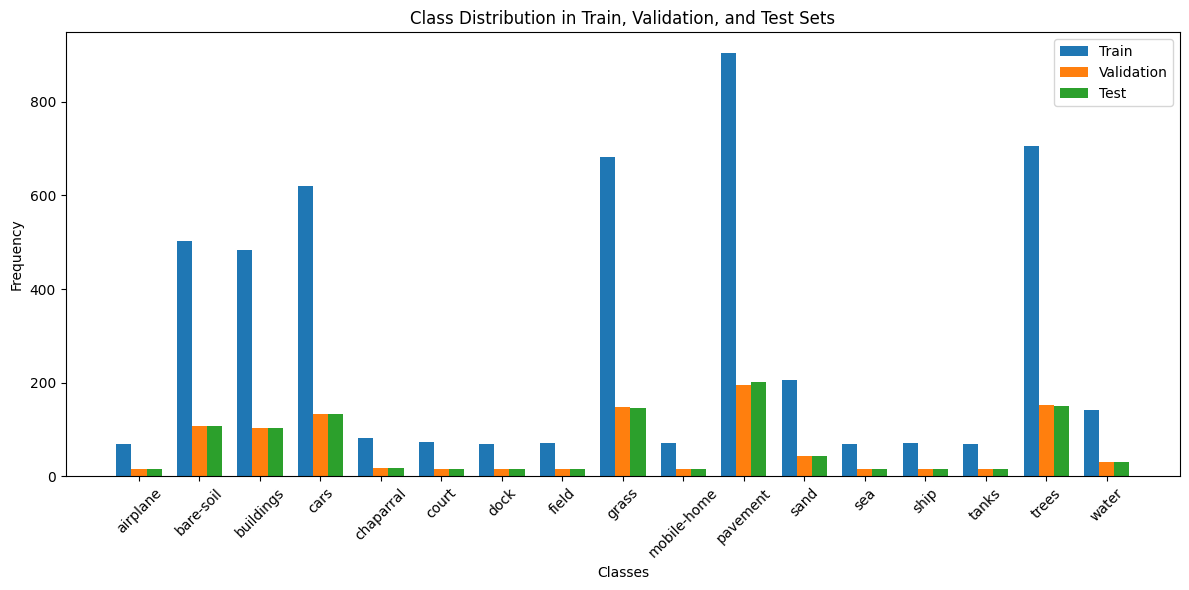

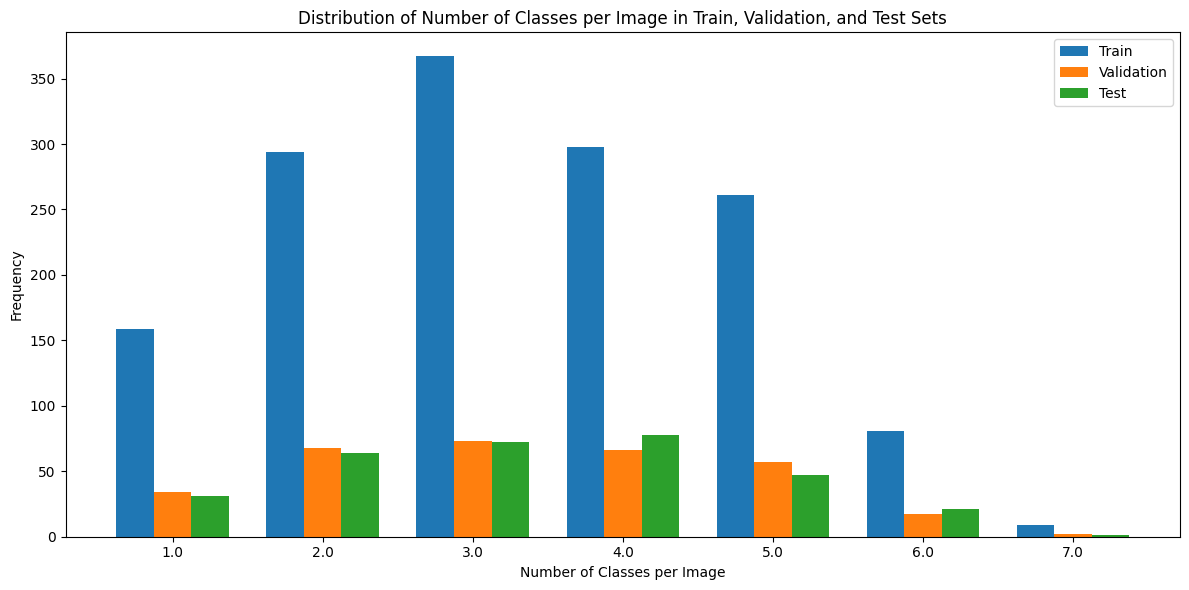

In [31]:
# DF appends the class frequencies
import numpy as np
distribution_df = pd.DataFrame({
    "class": classes,
    "train_freq": train_labels.sum(axis=0),
    "val_freq": val_labels.sum(axis=0),
    "test_freq": test_labels.sum(axis=0),
})

# Visualize the class distribution in a bar plot
def class_distribution_plot(distribution_df, classes):
    plt.figure(figsize=(12, 6))
    x = np.arange(len(classes))
    width = 0.25
    plt.bar(x - width, distribution_df["train_freq"], width, label="Train")
    plt.bar(x, distribution_df["val_freq"], width, label="Validation")
    plt.bar(x + width, distribution_df["test_freq"], width, label="Test")
    plt.xticks(x, classes, rotation=45)
    plt.xlabel("Classes")
    plt.ylabel("Frequency")
    plt.title("Class Distribution in Train, Validation, and Test Sets")
    plt.legend()
    plt.tight_layout()
    plt.savefig("outputs/Balanced_class_distribution.png")

class_distribution_plot(distribution_df, classes)

# Visualize number of classes per image for train val and test set
def image_distribution_plot(train_labels, val_labels, test_labels):
    plt.figure(figsize=(12, 6))
    train_counts = pd.Series(train_labels.sum(axis=1)).value_counts().sort_index()
    val_counts = pd.Series(val_labels.sum(axis=1)).value_counts().sort_index()
    test_counts = pd.Series(test_labels.sum(axis=1)).value_counts().sort_index()
    
    x = np.arange(len(train_counts.index))
    width = 0.25
    
    plt.bar(x - width, train_counts.values, width, label="Train")
    plt.bar(x, val_counts.values, width, label="Validation")
    plt.bar(x + width, test_counts.values, width, label="Test")
    
    plt.xticks(x, train_counts.index)
    plt.xlabel("Number of Classes per Image")
    plt.ylabel("Frequency")
    plt.title("Distribution of Number of Classes per Image in Train, Validation, and Test Sets")
    plt.legend()
    plt.tight_layout()
    plt.savefig("outputs/Image_class_count_distribution.png")

image_distribution_plot(train_labels, val_labels, test_labels)




Hyperparameters 

In [7]:
# Define hyperparameters
PRETRAINED_MODEL = "ViTB16"
NUM_CLASSES  = len(classes)
MAX_EPOCHS   = 25
EARLYSTOPPING_EPOCHS = 5
LR           = 1e-5        # ResNet usaba 1e-4; ViT necesita LR más bajo
WEIGHT_DECAY = 5e-2        # ViT típicamente usa weight_decay mayor


Load and train model

In [8]:
def build_vit_b16(num_classes):
    weights = tvm.ViT_B_16_Weights.IMAGENET1K_V1
    model = tvm.vit_b_16(weights=weights)
    # La cabeza de ViT en torchvision es model.heads (Sequential) con head -> Linear(768, 1000)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    return model

backbone = build_vit_b16(num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f"ViT-B/16 trainable parameters: {n_params:,}  |  output logits: {NUM_CLASSES}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 286MB/s] 


ViT-B/16 trainable parameters: 85,811,729  |  output logits: 17


Training

In [9]:
from utils import LightningModuleMultilabel 

lit_model = LightningModuleMultilabel(model=backbone, num_classes=NUM_CLASSES,
                                      lr=LR, weight_decay=WEIGHT_DECAY, max_epochs=MAX_EPOCHS, pos_weight=pos_w)
# Callbacks 
checkpoint_cb = ModelCheckpoint(
    dirpath="outputs/checkpoints",
    filename=f"{PRETRAINED_MODEL}-multilabel-best-{{epoch:02d}}-{{val_f1:.4f}}",
    monitor="val_f1", mode="max", save_top_k=1, save_weights_only=True,
)

early_stopping = EarlyStopping(
            monitor="val_loss",  
            patience=EARLYSTOPPING_EPOCHS,        # Number of epochs with no improvement
            mode="min",  
            min_delta=0.001,
            verbose=True
            )

# Logger to plot later
csv_logger = CSVLogger(save_dir="outputs/logs", name=f"{PRETRAINED_MODEL}_multilabel")

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    callbacks=[early_stopping, checkpoint_cb],
    logger=csv_logger,
    log_every_n_steps=10,
)
trainer.fit(lit_model, train_dataloaders=train_loader, val_dataloaders=val_loader)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA RTX PRO 6000 Blackwell Server Edition') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDr

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer          │ 85.8 M │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss          │      0 │ train │     0 │
│ 2 │ train_f1  │ MultilabelF1Score          │      0 │ train │     0 │
│ 3 │ val_f1    │ MultilabelF1Score          │      0 │ train │     0 │
│ 4 │ test_f1   │ MultilabelF1Score          │      0 │ train │     0 │
│ 5 │ val_acc   │ MultilabelAccuracy         │      0 │ train │     0 │
│ 6 │ test_acc  │ MultilabelAccuracy         │      0 │ train │     0 │
│ 7 │ val_map   │ MultilabelAveragePrecision │      0 │ train │     0 │
│ 8 │ test_map  │ MultilabelAveragePrecision │      0 │ train │     0 │
└───┴───────────┴────────────────────────────┴────────┴───────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 160                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.002 >= min_delta = 0.001. New best score: 0.162


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.007 >= min_delta = 0.001. New best score: 0.155


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.006 >= min_delta = 0.001. New best score: 0.150


INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.006 >= min_delta = 0.001. New best score: 0.144


INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 0.144. Signaling Trainer to stop.


Final classification on test data

In [10]:
# Evaluate using the best checkpoint
trainer.test(lit_model, dataloaders=test_loader, ckpt_path="best")

best_path = checkpoint_cb.best_model_path
print(f"Best checkpoint: {best_path}")
lit_model = LightningModuleMultilabel.load_from_checkpoint(best_path, model=lit_model.model)

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/ViTB16-multilabel-best-epoch=16-val_f1=0.9535.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/ViTB16-multilabel-best-epoch=16-val_f1=0.9535.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9653428792953491     │
│          test_f1          │    0.9503178596496582     │
│         test_loss         │    0.1395983099937439     │
│         test_map          │    0.9807043671607971     │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/drive/MyDrive/DL_Group_MGI1/outputs/checkpoints/ViTB16-multilabel-best-epoch=16-val_f1=0.9535.ckpt


In [11]:

# Collect probs, preds and ground-truth for downstream analysis
preds_out = trainer.predict(lit_model, dataloaders=test_loader)
test_probs  = torch.cat([b["probs"]  for b in preds_out], dim=0).cpu().numpy()
test_preds  = torch.cat([b["preds"]  for b in preds_out], dim=0).cpu().numpy()
test_labels = torch.cat([b["labels"] for b in preds_out], dim=0).cpu().numpy()


# Save to a CSV for later analysis
from utils import save_model_results
save_model_results(test_probs, test_preds, test_labels, classes, PRETRAINED_MODEL)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [12]:
from utils import compute_test_metrics

# Usage
metrics = compute_test_metrics(test_preds, test_labels, test_probs)

# Print metrics
print(f"\nTest accuracy   : {metrics['accuracy']:.4f}")
print(f"Test macro F1   : {metrics['macro_f1']:.4f}")
print(f"Test micro F1   : {metrics['micro_f1']:.4f}")
print(f"Test samples F1 : {metrics['samples_f1']:.4f}")
print(f"Test macro mAP  : {metrics['macro_map']:.4f}")
print(f"Hamming loss    : {metrics['hamming_loss']:.4f}")
print(f"Exact-match acc : {metrics['subset_acc']:.4f}")

# Export and append to a csv of the metrics f1 score of many other models and runs for comparison and plotting later
from utils import append_metrics_to_csv

append_metrics_to_csv(metrics, model_name="ML_" + PRETRAINED_MODEL + "_Balanced")




Test accuracy   : 0.9653
Test macro F1   : 0.9503
Test micro F1   : 0.9142
Test samples F1 : 0.9213
Test macro mAP  : 0.9807
Hamming loss    : 0.0347
Exact-match acc : 0.5701


Visualize

Saved training curves to: outputs/figures/ViTB16_training_curves.png


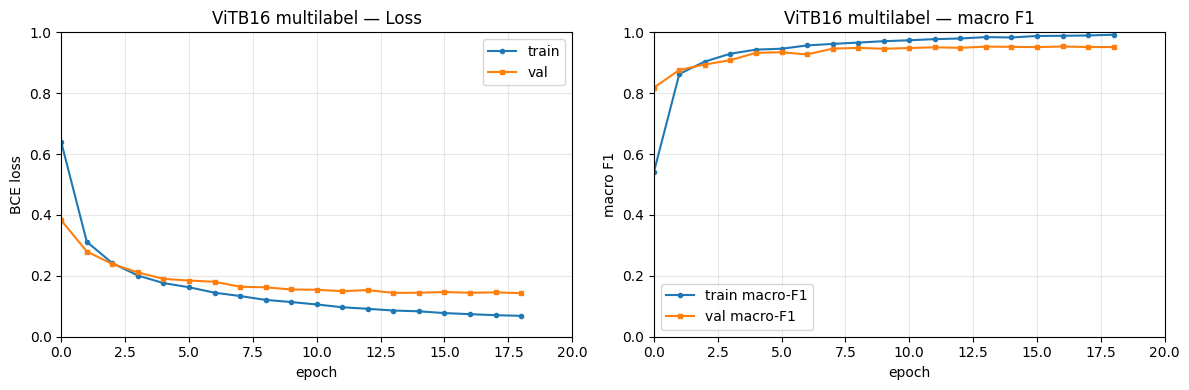

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'ViTB16 multilabel — Loss'}, xlabel='epoch', ylabel='BCE loss'>,
        <Axes: title={'center': 'ViTB16 multilabel — macro F1'}, xlabel='epoch', ylabel='macro F1'>],
       dtype=object))

In [19]:
# Usage
from utils import plot_training_curves
plot_training_curves(csv_logger, model_name=f"{PRETRAINED_MODEL} multilabel", 
                     save_path=f"outputs/figures/{PRETRAINED_MODEL}_training_curves.png")

Number of class per image accuracies

Saved to: results/ViTB16_metrics_by_class_count.png


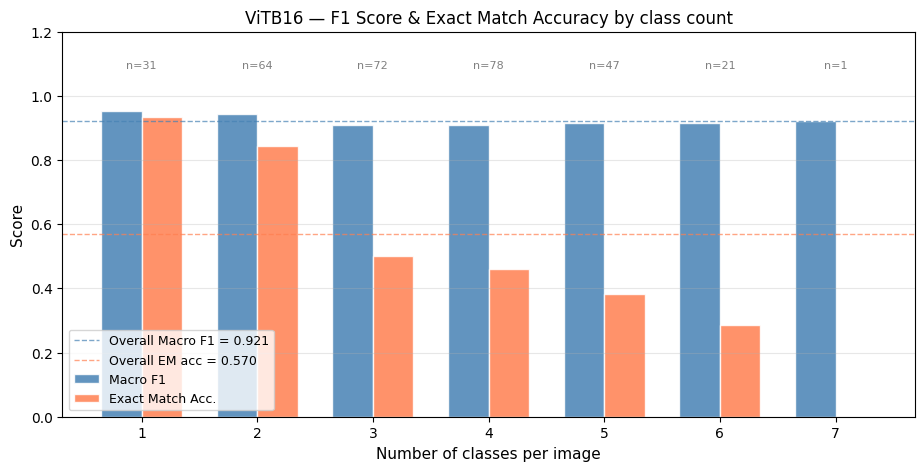

In [35]:
from utils import plot_metrics_by_class_count
fig, ax = plot_metrics_by_class_count(
    preds=test_preds,
    labels=test_labels,
    model_name=PRETRAINED_MODEL,
    save_path=f"results/{PRETRAINED_MODEL}_metrics_by_class_count.png"
)

Examples of images

Saved prediction grid to: outputs/ViTB16_multilabel_predictions_grid.png


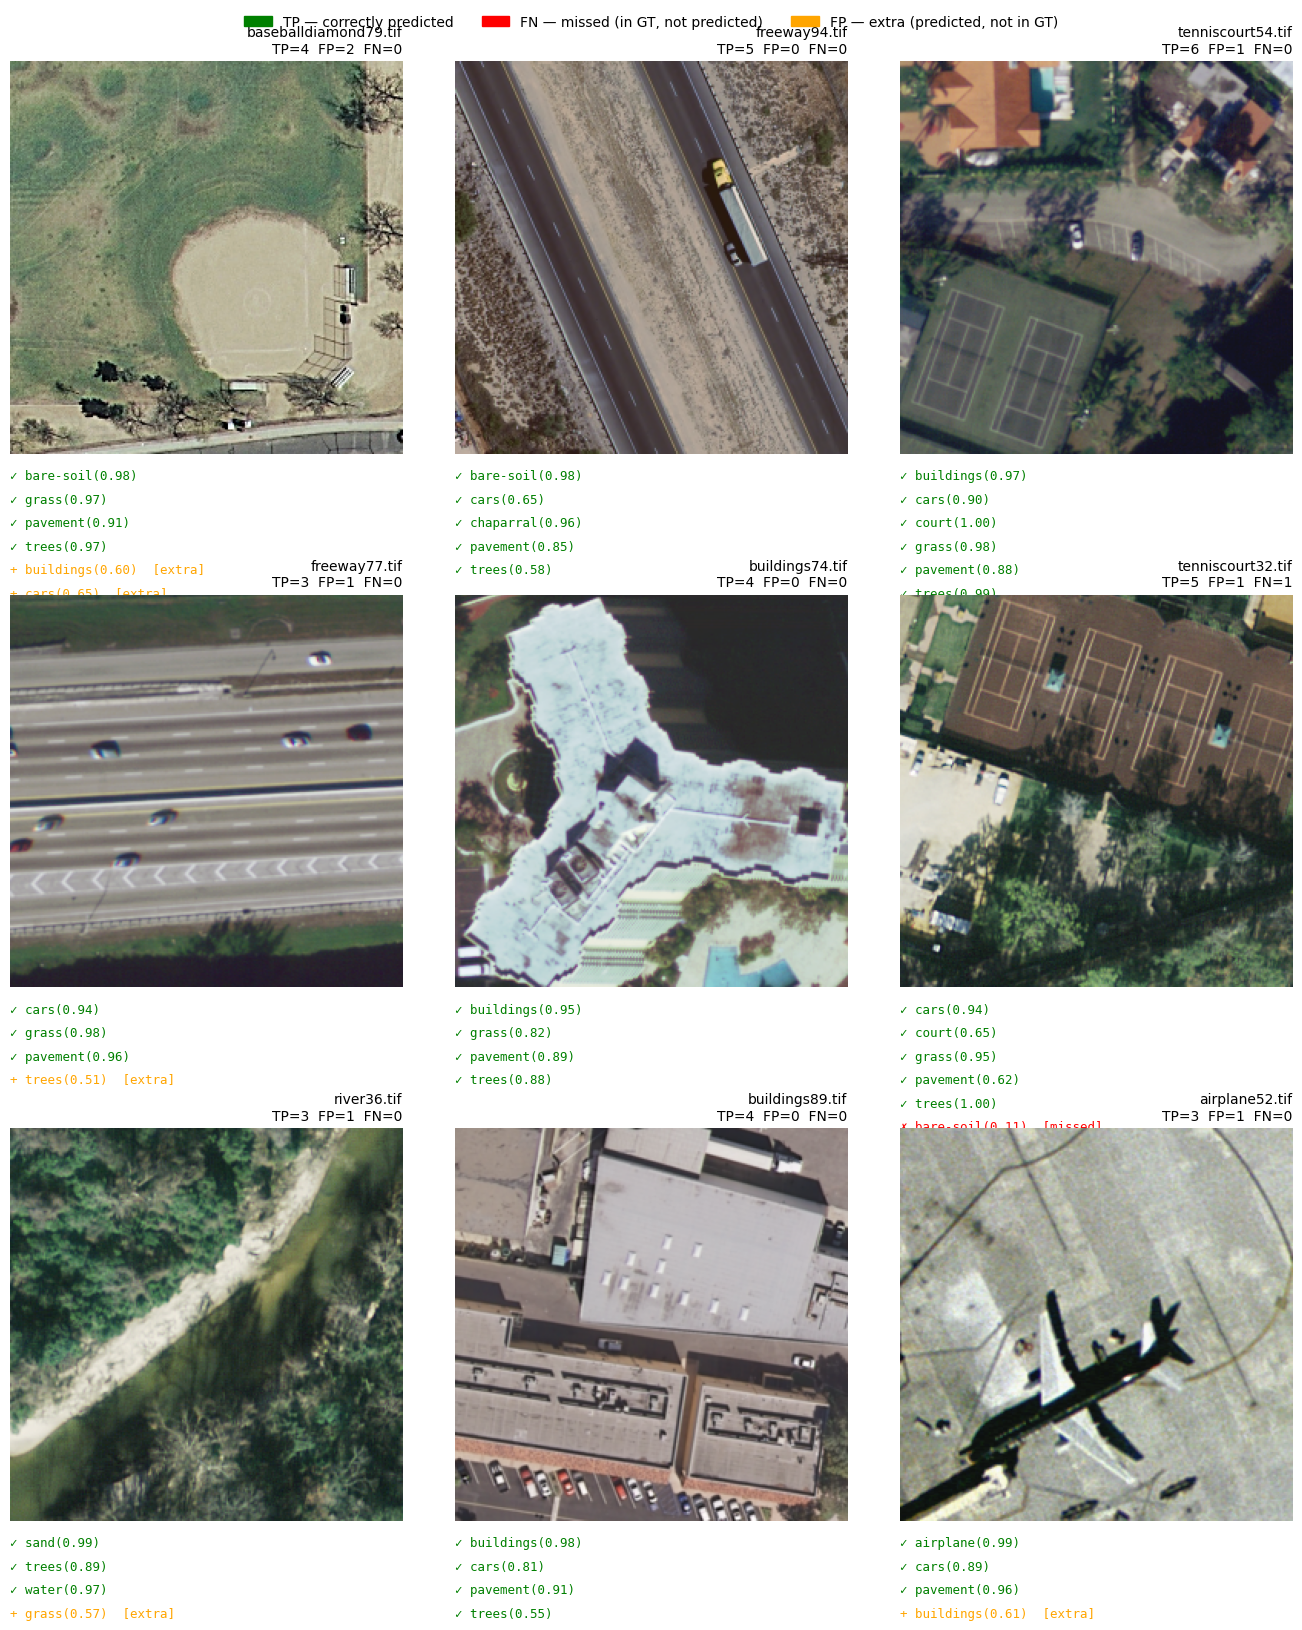

In [30]:

from utils import plot_prediction_grid
fig = plot_prediction_grid(
    test_preds=test_preds,
    test_labels=test_labels,
    test_probs=test_probs,
    classes=classes,
    test_loader=test_loader,
    root_dir="ucmdata",
    label_file="LandUse_Multilabeled.txt",
    n_show=9,
    seed=5,
    save_path=f"outputs/{PRETRAINED_MODEL}_multilabel_predictions_grid.png"
)